In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# create our numpy random number generator
rng = np.random.default_rng(42)

## The Central Limit Theorem
In a previous lesson we saw the law of large numbers. It states that when we look at the sampling distribution of the mean, the mean will be the same as the mean of the underlying distribution. 
- For example, if we flip 10 coins again and again, we won't get 5 every time. But we'll get an average of 5 if we do it lots of times.

And the standard deviation of the sampling distribution gets smaller as the size of the samples gets bigger.
- For example, if we flip 100 coins lots of times, most of the results will be closer to 50% heads than if we flip 10 coins lots of times. And if we flip 100,000 coins, while we won't get exactly 50,000, we'll get pretty close to 50% heads.

The Central Limit Theorem states something else. It says that the sampling distribution of the mean always approaches the *shape* of a normal distribution as the sample sizes get bigger, regardless of the shape of the original distribution. It's a pretty remarkable result!

Let's see how that looks empirically for for some underlying distributions that we've seen before, including ones that are really far from normal distributions.

In [3]:
# plot the histogram of a dataset generated from a discrete distribution
def plot_discrete(data, ax, colname="statistic", num_ticks=None, min_x=None, max_x=None):
    sns.histplot(data, x=colname, ax=ax)

    # keep a limited set of labeled ticks on the x-axis, evenly spaced, for legibility
    if num_ticks is not None:
        ax.xaxis.set_major_locator(plt.MaxNLocator(6))

    # Set the range of the x-axis if min_x and max_x are provided
    if min_x is not None and max_x is not None:
        ax.set_xlim(min_x, max_x)

# plot the histogram of a dataset generated from a continuous distribution, by binning the data
def plot_continuous(data, ax, colname="statistic", num_bins=100, min_x=None, max_x=None):
    sns.histplot(data[colname], ax=ax, stat="probability")

    # Set the range of the x-axis if min_x and max_x are provided
    if min_x is not None and max_x is not None:
        ax.set_xlim(min_x, max_x)

    ax.set_ylabel("Probability")


In [4]:
# repeated from an earlier notebook
def simulate_sampling_distribution(
    underlying_distribution_simulator, sample_statistic, n_simulations=1000, sample_size=100
):
    samples = [underlying_distribution_simulator(sample_size) for _ in range(n_simulations)]
    return pd.DataFrame(
        {
            "statistic": [sample_statistic(sample) for sample in samples],
        }
    )

In [5]:
def simulate_clt(
    underlying_distribution_simulator,  # function that simulates the underlying distribution, returning a dataframe with a column named "Outcome"
    discrete=True,  # whether the underlying distribution is discrete or continuous; affects our plot of the underlying distribution
    n_simulations=1000,
):
    # Create a figure with 4 subplots
    fig, axes = plt.subplots(1, 4, figsize=(12, 3))
    plt.subplots_adjust(wspace=0.5)

    # Simulate the underlying distribution
    underlying_distribution_df = underlying_distribution_simulator(n_simulations)

    min_x = underlying_distribution_df["Outcome"].min()
    max_x = underlying_distribution_df["Outcome"].max()

    # Plot the underlying distribution on the first axes object
    ax = axes[0]
    if discrete:
        plot_discrete(underlying_distribution_df, ax, colname="Outcome", min_x=min_x, max_x=max_x)
    else:
        plot_continuous(underlying_distribution_df, ax, colname="Outcome", min_x=min_x, max_x=max_x)
    ax.set_title("Underlying Distribution")
    ax.set_xlabel("")


    # plot figures for sampling distribution of the mean for samples of size 5, 50, and 500
    for ax, sample_size in zip(axes[1:], [5, 50, 500]):
        # Simulate the sampling distribution
        sample_statistics_df = simulate_sampling_distribution(
            underlying_distribution_simulator,
            sample_statistic=lambda df: df["Outcome"].mean(),
            n_simulations=n_simulations,
            sample_size=sample_size,
        )

        plot_continuous(
            sample_statistics_df,
            ax,
            colname="statistic",
            min_x=min_x,
            max_x=max_x,
        )
        ax.set_title(f"mean of n={sample_size}")
        ax.set_xlabel("")

    # Display the plot
    plt.show()

Simulate sample means for increasing sample sizes for Poisson with lambda = 1.5

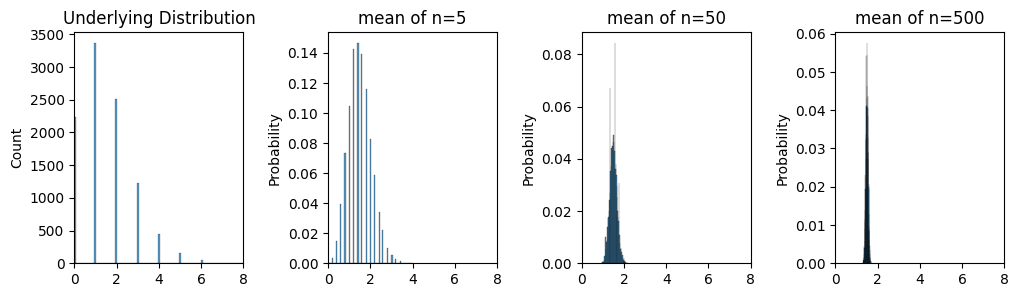

In [6]:
simulate_clt(
    underlying_distribution_simulator=lambda n: pd.DataFrame(
        rng.poisson(lam=1.5, size=n), columns=["Outcome"]
    ),
    n_simulations=10000,
    discrete=True,
    )

Let's try it for the binomial distribution: count of heads in 10 coin flips, with probability 0.7 on each flip.

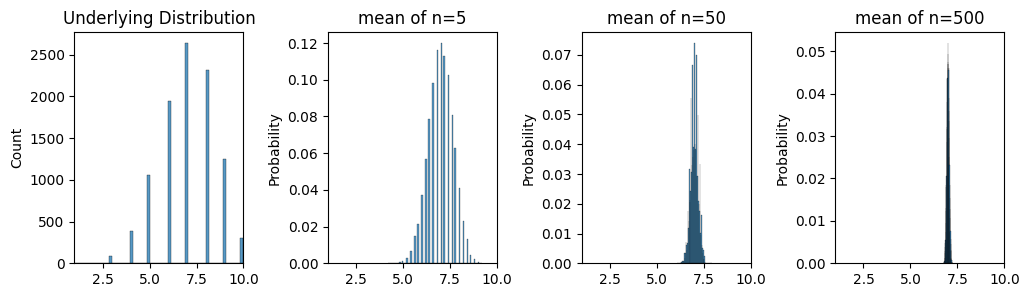

In [7]:
simulate_clt(
    underlying_distribution_simulator=lambda n: pd.DataFrame(
        rng.binomial(n=10, p=0.7, size=n), columns=["Outcome"]
    ),
    n_simulations=10000,
    discrete=True,
)

Now for our first continuous distribution, one with two "humps"

In [8]:
def sample_mix_of_two_betas(alpha1=1, beta1=5, alpha2=5, beta2=1, mix=0.5, n=1000):
    which = rng.choice([1, 2], size=n, p=[mix, 1 - mix])
    b1 = rng.beta(alpha1, beta1, n)
    b2 = rng.beta(alpha2, beta2, n)
    df = pd.DataFrame({"Outcome": np.where(which == 1, b1, b2)})
    return df

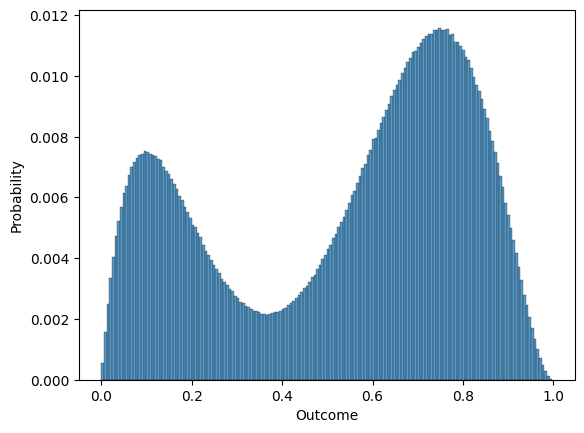

In [9]:
plot_continuous(sample_mix_of_two_betas(2, 10, 7, 3, mix=0.3, n=5000000), plt.gca(), colname="Outcome")

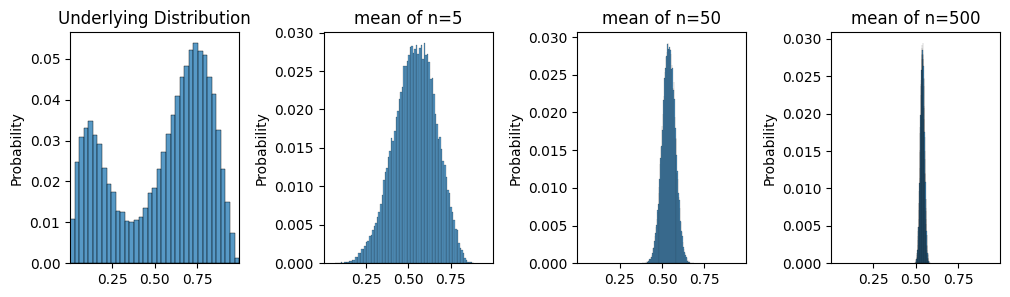

In [10]:
simulate_clt(
    underlying_distribution_simulator=lambda n: pd.DataFrame(
        sample_mix_of_two_betas(2, 10, 7, 3, mix=0.3, n=n), columns=["Outcome"]
    ),
    n_simulations=50000,
    discrete=False,
)

And for an exponential distribution

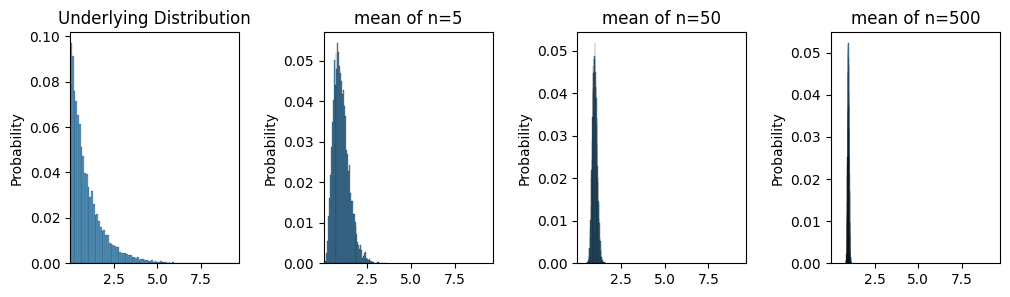

In [11]:
simulate_clt(
    underlying_distribution_simulator=lambda n: pd.DataFrame(
        np.random.default_rng().exponential(scale=1, size=n), columns=["Outcome"]
    ),
    n_simulations=10000,
    discrete=False,
)